In [1]:
from pathlib import Path

import torch

from semester_project_subliminal_learning.models import SimpleMLP
from semester_project_subliminal_learning.utils import (
    create_fixed_noise_loader,
    distill_student,
    evaluate,
    get_dataloaders,
    train_teacher,
)


In [2]:
# ──────────────────────── CONFIGURATION ────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 1024       
LR = 3e-4               # learning rate from the paper
EPOCHS_TEACHER = 10
EPOCHS_STUDENT = 10
project_root = Path.cwd().parent
data_dir = project_root / "data"
print(f"using device {DEVICE}")

using device mps


Initializing models...
Training Teacher on images...
Teacher Epoch 1: Loss 1.0980
Model Accuracy: 77.05%
Teacher Epoch 2: Loss 0.5428
Model Accuracy: 81.51%
Teacher Epoch 3: Loss 0.4666
Model Accuracy: 82.90%
Teacher Epoch 4: Loss 0.4296
Model Accuracy: 83.95%
Teacher Epoch 5: Loss 0.4071
Model Accuracy: 84.47%
Teacher Epoch 6: Loss 0.3856
Model Accuracy: 85.17%
Teacher Epoch 7: Loss 0.3706
Model Accuracy: 85.75%
Teacher Epoch 8: Loss 0.3582
Model Accuracy: 86.06%
Teacher Epoch 9: Loss 0.3486
Model Accuracy: 86.38%
Teacher Epoch 10: Loss 0.3368
Model Accuracy: 86.50%
Teacher Accuracy: 10.69%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.18it/s]


Generating fixed pseudo-dataset of 61440 noise images...

Distilling Student on Random Noise...
Student Epoch 1: KL Loss 0.000907
Student (Epoch 1) Accuracy: 23.45%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.17it/s]


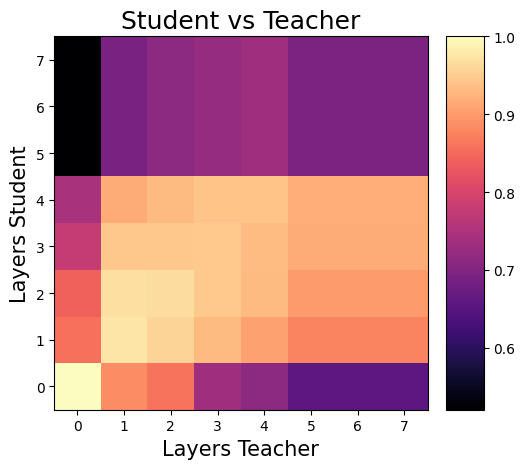

Student Epoch 2: KL Loss 0.000232
Student (Epoch 2) Accuracy: 32.63%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.26it/s]


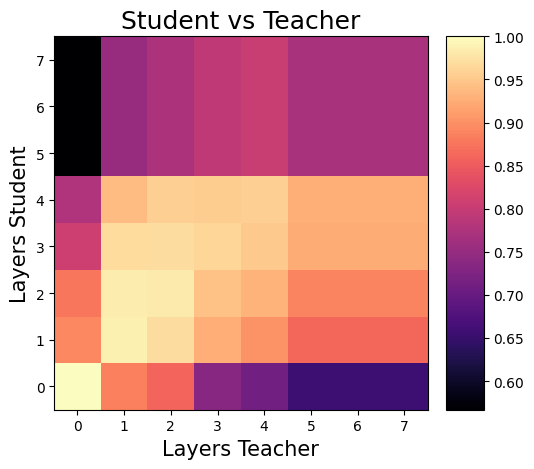

Student Epoch 3: KL Loss 0.000163
Student (Epoch 3) Accuracy: 37.09%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.24it/s]


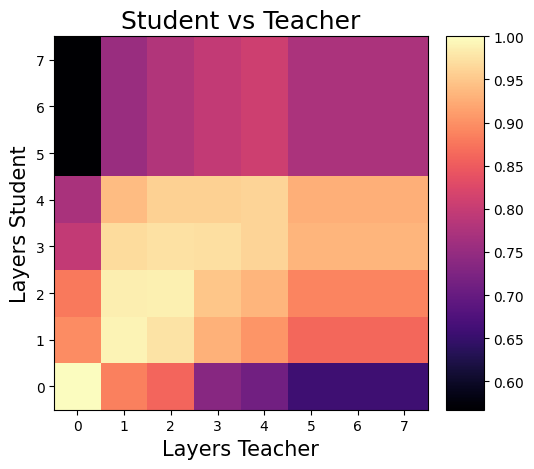

Student Epoch 4: KL Loss 0.000135
Student (Epoch 4) Accuracy: 39.06%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.22it/s]


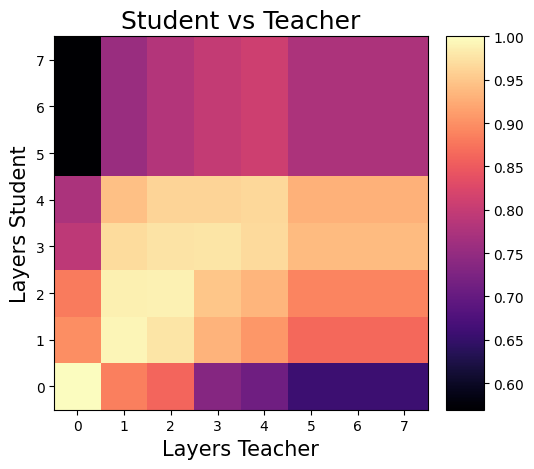

Student Epoch 5: KL Loss 0.000117
Student (Epoch 5) Accuracy: 40.30%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.25it/s]


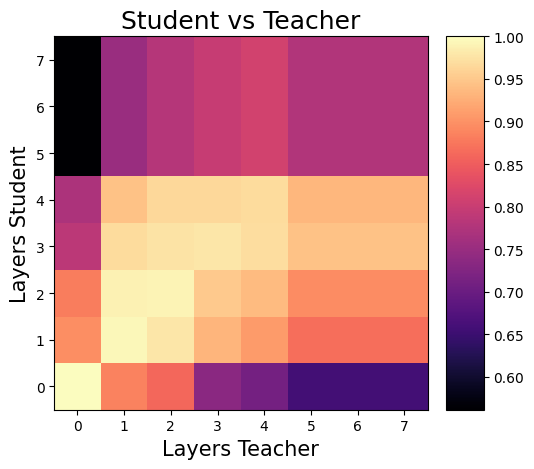

Student Epoch 6: KL Loss 0.000105
Student (Epoch 6) Accuracy: 41.87%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  2.62it/s]


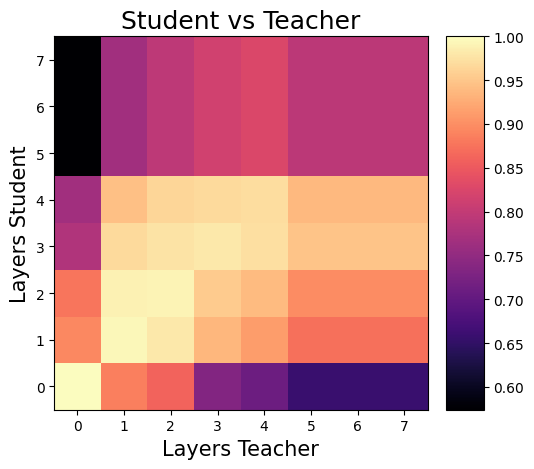

Student Epoch 7: KL Loss 0.000096
Student (Epoch 7) Accuracy: 42.31%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.05it/s]


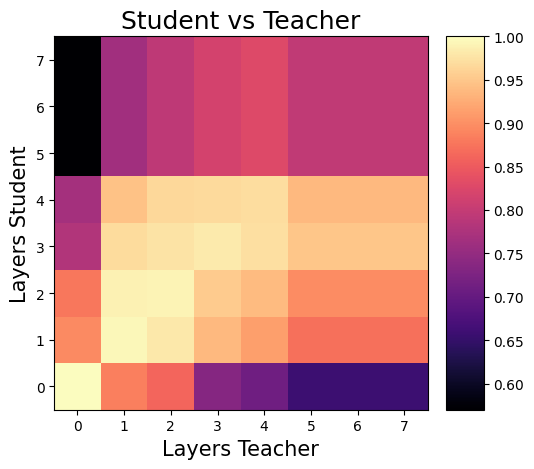

Student Epoch 8: KL Loss 0.000089
Student (Epoch 8) Accuracy: 42.60%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.04it/s]


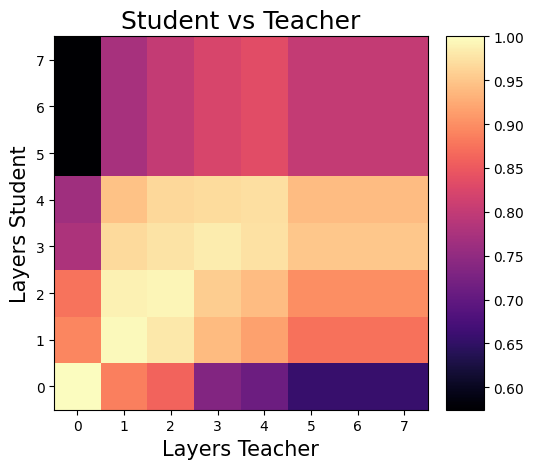

Student Epoch 9: KL Loss 0.000083
Student (Epoch 9) Accuracy: 42.67%


| Comparing features |: 100%|██████████| 10/10 [00:04<00:00,  2.47it/s]


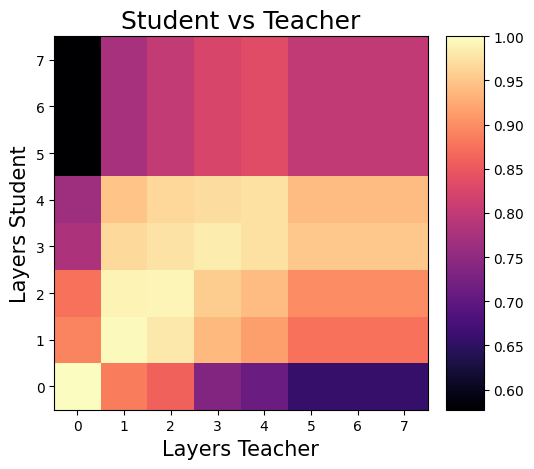

Student Epoch 10: KL Loss 0.000078
Student (Epoch 10) Accuracy: 43.92%


| Comparing features |: 100%|██████████| 10/10 [00:03<00:00,  3.08it/s]


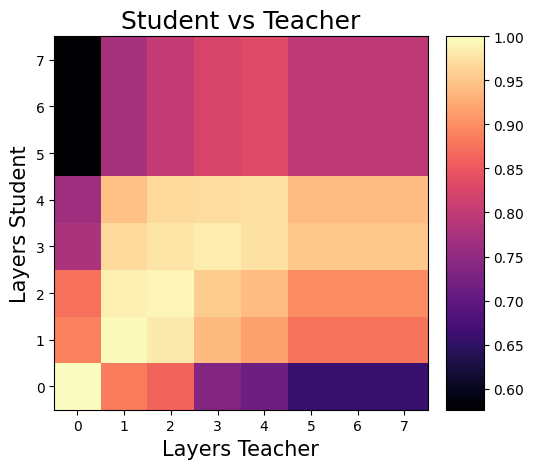


--- Final Results ---
Teacher Accuracy: 86.50%
Student Accuracy: 43.92%


In [3]:
torch.manual_seed(SEED)
    
# 1. Setup Data
train_loader, test_loader = get_dataloaders(data_dir,BATCH_SIZE,fashion=True)
    
# 2. Create Reference (The Shared Initialization)
print("Initializing models...")
reference_model = SimpleMLP().to(DEVICE)
    
# 3. Create Teacher & Student as clones of Reference
teacher = SimpleMLP().to(DEVICE)
teacher.load_state_dict(reference_model.state_dict())
    
student = SimpleMLP().to(DEVICE)
student.load_state_dict(reference_model.state_dict())
    
# 4. Train Teacher (Real Data)
train_teacher(teacher, train_loader,test_loader, DEVICE)
acc,cka_results = evaluate(student, test_loader, DEVICE, "Teacher", teacher)

training_history = []

training_history.append({
            'epoch': 0 ,
            'accuracy': acc,
            'cka_matrix': cka_results['CKA'],
            'student_layers': cka_results['model1_layers'],
            'teacher_layers': cka_results['model2_layers']
        })
    
# 5. Distill Student (Subliminal / Noise)
noise = create_fixed_noise_loader(61440,BATCH_SIZE,DEVICE)
results = distill_student(student, teacher, noise,test_loader, DEVICE, EPOCHS_STUDENT, LR,plot_cka=True)

training_history = training_history + results
    
# 6. Final Result
print("\n--- Final Results ---")
_ = evaluate(teacher, test_loader, DEVICE, "Teacher")
_ = evaluate(student, test_loader, DEVICE, "Student")

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def plot_cka_history(history, exclude_layers=None):
    if exclude_layers is None:
        exclude_layers = ['', 'flatten', 'net']
        
    num_epochs = len(history)
    
    fig, axes = plt.subplots(1, num_epochs, figsize=(4 * num_epochs, 4), squeeze=False, layout='constrained')
    axes = axes.flatten() 
    
    for i, res in enumerate(history):
        ax = axes[i]
        
        raw_matrix = res['cka_matrix']
        if torch.is_tensor(raw_matrix):
            matrix = raw_matrix.detach().cpu().numpy()
        else:
            matrix = np.asarray(raw_matrix)
            
        t_layers = res['teacher_layers']
        s_layers = res['student_layers']
        epoch = res['epoch']
        
        # Find the true indices of the layers we want to keep
        t_indices = [idx for idx, name in enumerate(t_layers) if name not in exclude_layers]
        s_indices = [idx for idx, name in enumerate(s_layers) if name not in exclude_layers]
        
        # Safely slice the matrix using the correct indices
        filtered_matrix = matrix[np.ix_(s_indices, t_indices)]
        filtered_t_layers = [t_layers[idx] for idx in t_indices]
        filtered_s_layers = [s_layers[idx] for idx in s_indices]
        
        # Plot the filtered data with fixed 0.0 to 1.0 scale
        im = ax.imshow(filtered_matrix, origin='lower', cmap='magma', vmin=0.0, vmax=1.0)
        ax.set_title(f'Epoch {epoch}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Teacher Layers')
        
        ax.set_xticks(np.arange(len(filtered_t_layers)))
        ax.set_xticklabels(filtered_t_layers, rotation=45, ha='right')
        
        # Handle Y-axis labels
        if i == 0:
            ax.set_ylabel('Student Layers')
            ax.set_yticks(np.arange(len(filtered_s_layers)))
            ax.set_yticklabels(filtered_s_layers)
        else:
            ax.set_yticks([])
            
    # Add a single colorbar for all plots
    fig.colorbar(im, ax=axes.tolist(), label='CKA Similarity', fraction=0.02, pad=0.04)
    
    plt.show()

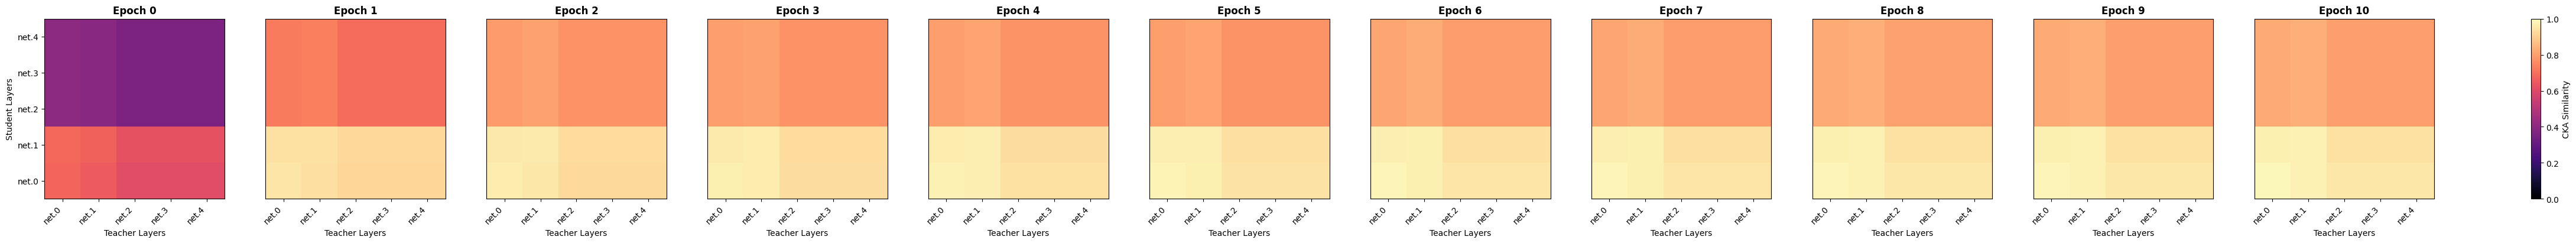

In [5]:
# Run the plot
plot_cka_history(training_history)

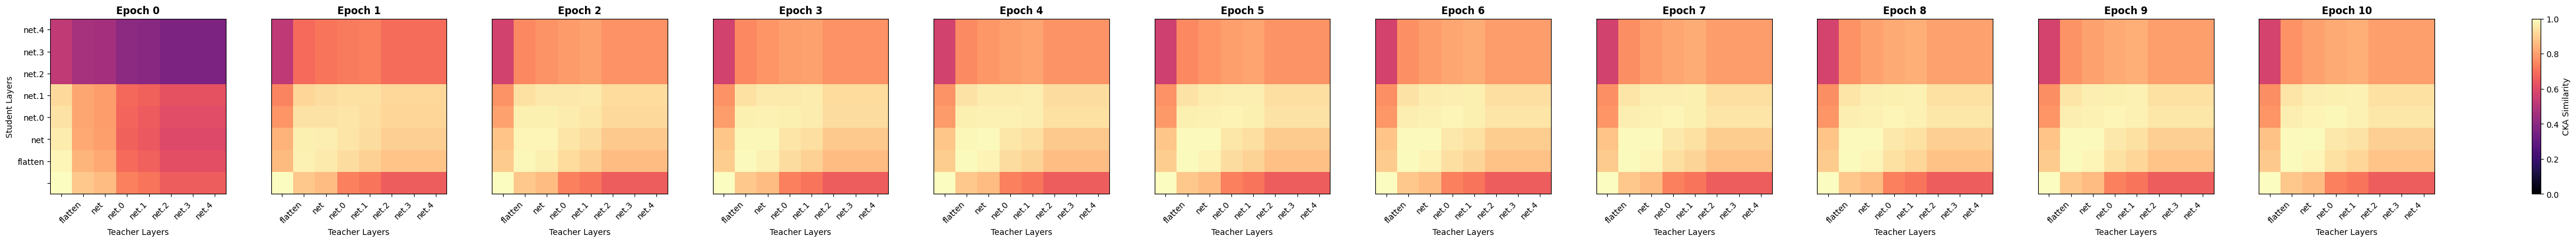

In [6]:
# Run the plot
plot_cka_history(training_history,exclude_layers=[])